# Evaluation of Results for Weasel v2.0 and other classifiers

In [86]:
import glob
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 20)

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import seaborn as sns
import os
from multi_comp_matrix import MCM
from IPython.display import Image, display


In [54]:
def _latest(pattern):
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matching: {pattern}")
    return files[-1]

df = pd.concat([
    pd.read_csv("../benchmark/ucr-test-accuracy-1.csv"),
    pd.read_csv("../benchmark/ucr-test-accuracy-otherclfs-1.csv"),
], ignore_index=True)

df_rt = pd.concat([
    pd.read_csv("../benchmark/ucr-test-runtime-1.csv"),
    pd.read_csv("../benchmark/ucr-test-runtime-otherclfs-1.csv"),
], ignore_index=True)

mapping = {
    "WEASEL 2.0":  "WEASEL 2.0 (D)",
    "WEASEL":      "WEASEL (D)",
    "MultiRocket": "MultiRocket (K)",
    "Rocket":      "Rocket (K)",
    "MiniRocket":  "MiniRocket (K)",
    "R_DST":       "R_DST (S)",
    "Hydra (K/D)": "Hydra (K/D)",
    "cBOSS (D)":       "cBOSS (D)",
}

for old, new in mapping.items():
    df.Classifier    = df.Classifier.replace({old: new})
    df_rt.Classifier = df_rt.Classifier.replace({old: new})


print(df_rt.head())
print(df.Classifier.value_counts())
print(df_rt.Classifier.value_counts())

        Classifier             Dataset  Fit-Time  Predict-Time
0  MultiRocket (K)               ACSF1      3.17          1.83
1  MultiRocket (K)               Adiac      2.20          1.45
2  MultiRocket (K)  AllGestureWiimoteX      4.87          9.11
3  MultiRocket (K)  AllGestureWiimoteY      5.12          9.78
4  MultiRocket (K)  AllGestureWiimoteZ      5.42          9.97
Classifier
MultiRocket (K)    128
R_DST (S)          128
Rocket (K)         128
MiniRocket (K)     128
WEASEL 2.0 (D)     128
cBOSS (D)          128
Hydra (K/D)        127
WEASEL (D)         125
Name: count, dtype: int64
Classifier
MultiRocket (K)    128
R_DST (S)          128
Rocket (K)         128
MiniRocket (K)     128
WEASEL 2.0 (D)     128
cBOSS (D)          128
Hydra (K/D)        127
WEASEL (D)         125
Name: count, dtype: int64


In [55]:
pd.set_option('display.max_rows', 500)
df_pivot = df.pivot(index="Dataset", columns=["Classifier"], values=["Accuracy"])  # .iloc[:-5]

df_pivot.reset_index(drop=True)
df_pivot.columns = df_pivot.columns.get_level_values(1)
#df_pivot.dropna(inplace=True)
df_pivot = df_pivot.round(4)
# print(df_pivot.shape)
display(df_pivot)
df_pivot.describe()

Classifier,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Dataset,,,,,,,,
ACSF1,0.8800,0.9100,0.9000,0.9200,0.8800,0.8700,0.9400,0.8900
Adiac,0.8210,0.8363,0.8286,0.7238,0.7852,0.8107,0.8414,0.7903
AllGestureWiimoteX,0.6714,0.7300,0.7600,0.7114,0.7271,0.6157,0.7014,0.5886
AllGestureWiimoteY,0.7200,0.7543,0.7757,0.7100,0.7486,0.5700,0.7043,0.6314
AllGestureWiimoteZ,0.6900,0.7286,0.7643,0.6800,0.7286,0.5186,0.7029,0.6086
ArrowHead,0.8114,0.8629,0.8629,0.8686,0.8171,0.8743,0.8571,0.8171
BME,1.0000,1.0000,1.0000,0.9933,1.0000,0.9133,0.9800,0.6667
Beef,0.8667,0.8333,0.7667,0.8333,0.8000,0.8333,0.8333,0.6667
BeetleFly,0.9000,0.9000,0.8500,0.9500,0.9000,0.7500,0.9500,0.9500


Classifier,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
count,127.000000,128.000000,128.000000,128.000000,128.000000,125.000000,128.000000,128.000000
mean,0.848975,0.854569,0.860670,0.858413,0.851212,0.812750,0.855889,0.797154
std,0.148534,0.145668,0.140703,0.139597,0.147693,0.177244,0.147100,0.182520
min,0.318600,0.285900,0.358600,0.338100,0.282200,0.313300,0.347000,0.059100
25%,0.769850,0.773725,0.787025,0.768025,0.779750,0.714700,0.775350,0.684575
50%,0.898800,0.907100,0.911400,0.896500,0.900000,0.860500,0.912050,0.832450
75%,0.968900,0.966775,0.973075,0.977250,0.967450,0.961500,0.967000,0.950000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [56]:
df_pivot.columns

Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')

In [57]:
# df_pivot.to_excel("data.xls")
df_pivot.describe().loc[["mean", "50%", "std"]].T.round(3)

,mean,50%,std
Classifier,,,
Hydra (K/D),0.849,0.899,0.149
MiniRocket (K),0.855,0.907,0.146
MultiRocket (K),0.861,0.911,0.141
R_DST (S),0.858,0.897,0.140
Rocket (K),0.851,0.900,0.148
WEASEL (D),0.813,0.860,0.177
WEASEL 2.0 (D),0.856,0.912,0.147
cBOSS (D),0.797,0.832,0.183


Datasets before: 128, after dropping NaN rows: 124


Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,4.6,4.69,3.83,4.34,4.58,6.29,4.42,6.63


(0, 'Hydra (K/D)'):  	 ties/wins=(28, 12)
(1, 'MiniRocket (K)'):  	 ties/wins=(20, 5)
(2, 'MultiRocket (K)'):  	 ties/wins=(46, 27)
(3, 'R_DST (S)'):  	 ties/wins=(33, 15)
(4, 'Rocket (K)'):  	 ties/wins=(30, 9)
(5, 'WEASEL (D)'):  	 ties/wins=(14, 6)
(6, 'WEASEL 2.0 (D)'):  	 ties/wins=(29, 14)
(7, 'cBOSS (D)'):  	 ties/wins=(15, 3)
Total:  	124


  0%|          | 0/3 [07:30<?, ?it/s]


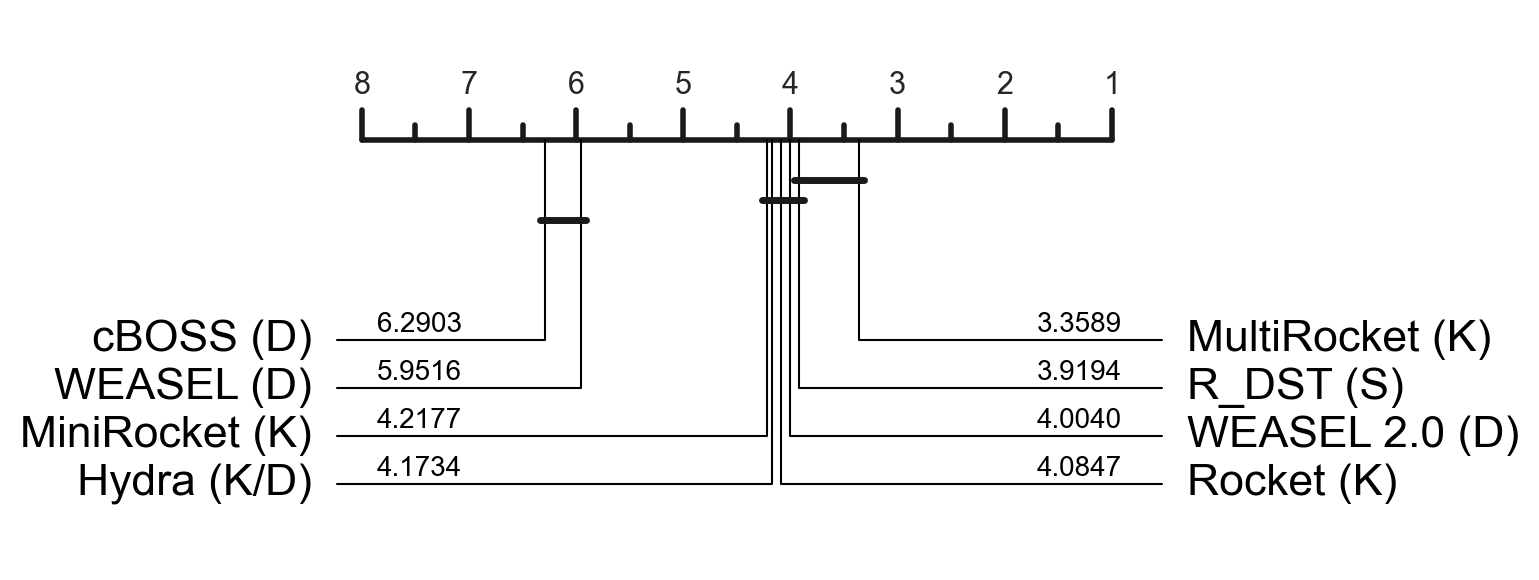

Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,4.6,4.69,3.83,4.34,4.58,6.29,4.42,6.63


In [58]:
from aeon.visualisation import plot_critical_difference

def critical_difference(df_subset, show=True):
    ranks = df_subset.rank(1, method = 'max', ascending=False)
    # print(ranks)
    mean_ranks = np.array(ranks.mean(axis=0))

    df_ranks = pd.DataFrame(
        list(zip(df_subset.columns.values, np.round(mean_ranks,2))), 
        columns=["Classifer", "Mean Rank"]).set_index("Classifer").T
    
    if show:
        display(df_ranks)
        for i, name in enumerate(df_subset.columns[0:]):
           print(f"{i, name}:  \t ties/wins={ranks[ranks[name] == np.min(ranks, axis=1)].shape[0], ranks[ranks[name] == 1].shape[0]}")

        print(f"Total:  \t{len(ranks)}")


    fig,ax = plot_critical_difference(df_subset.values, list(df_subset.columns))
    
    plt.show()
    
    return df_ranks



df_subset = df_pivot 
df_clean = df_subset.dropna(axis=0)

print(f"Datasets before: {len(df_subset)}, after dropping NaN rows: {len(df_clean)}")

critical_difference(df_clean)

Classifer,Hydra (K/D),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,2.11,3.15,2.09,3.31


(0, 'Hydra (K/D)'):  	 ties/wins=(61, 43)
(1, 'WEASEL (D)'):  	 ties/wins=(17, 8)
(2, 'WEASEL 2.0 (D)'):  	 ties/wins=(62, 42)
(3, 'cBOSS (D)'):  	 ties/wins=(21, 8)
Total:  	124


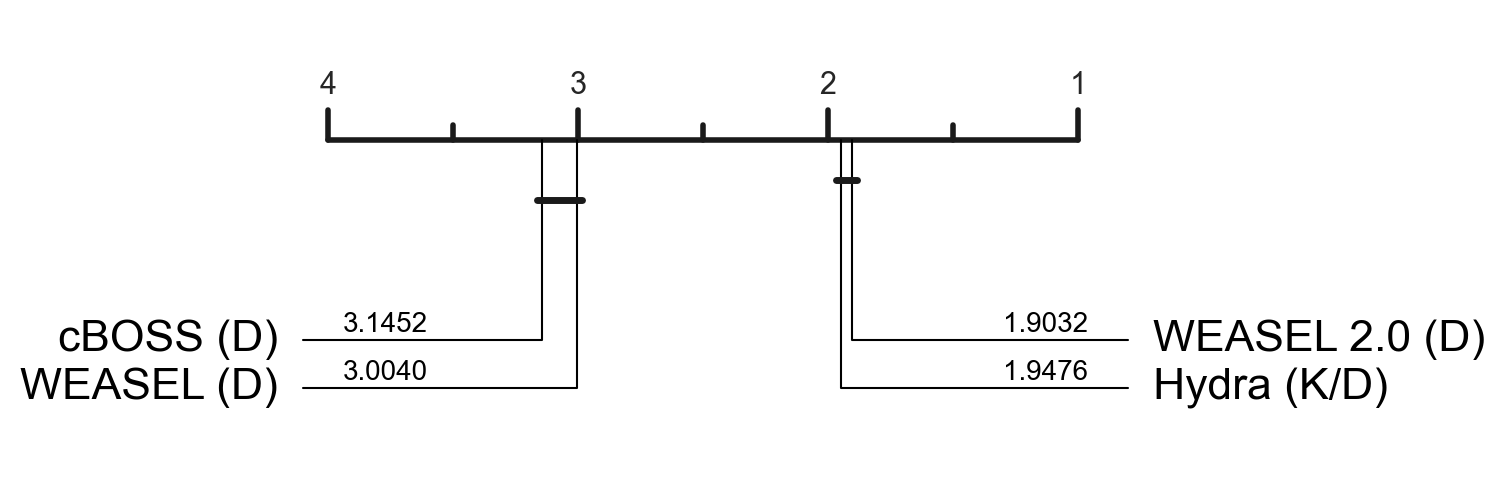

Classifer,Hydra (K/D),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,2.11,3.15,2.09,3.31


In [59]:
subset = [0, 5,6,7] # plot just dictionary based methods
df_subset2 = df_clean.iloc[:, subset]
critical_difference(df_subset2, True)

In [60]:
print(df_clean.columns)
print(df_pivot.columns)

Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')
Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


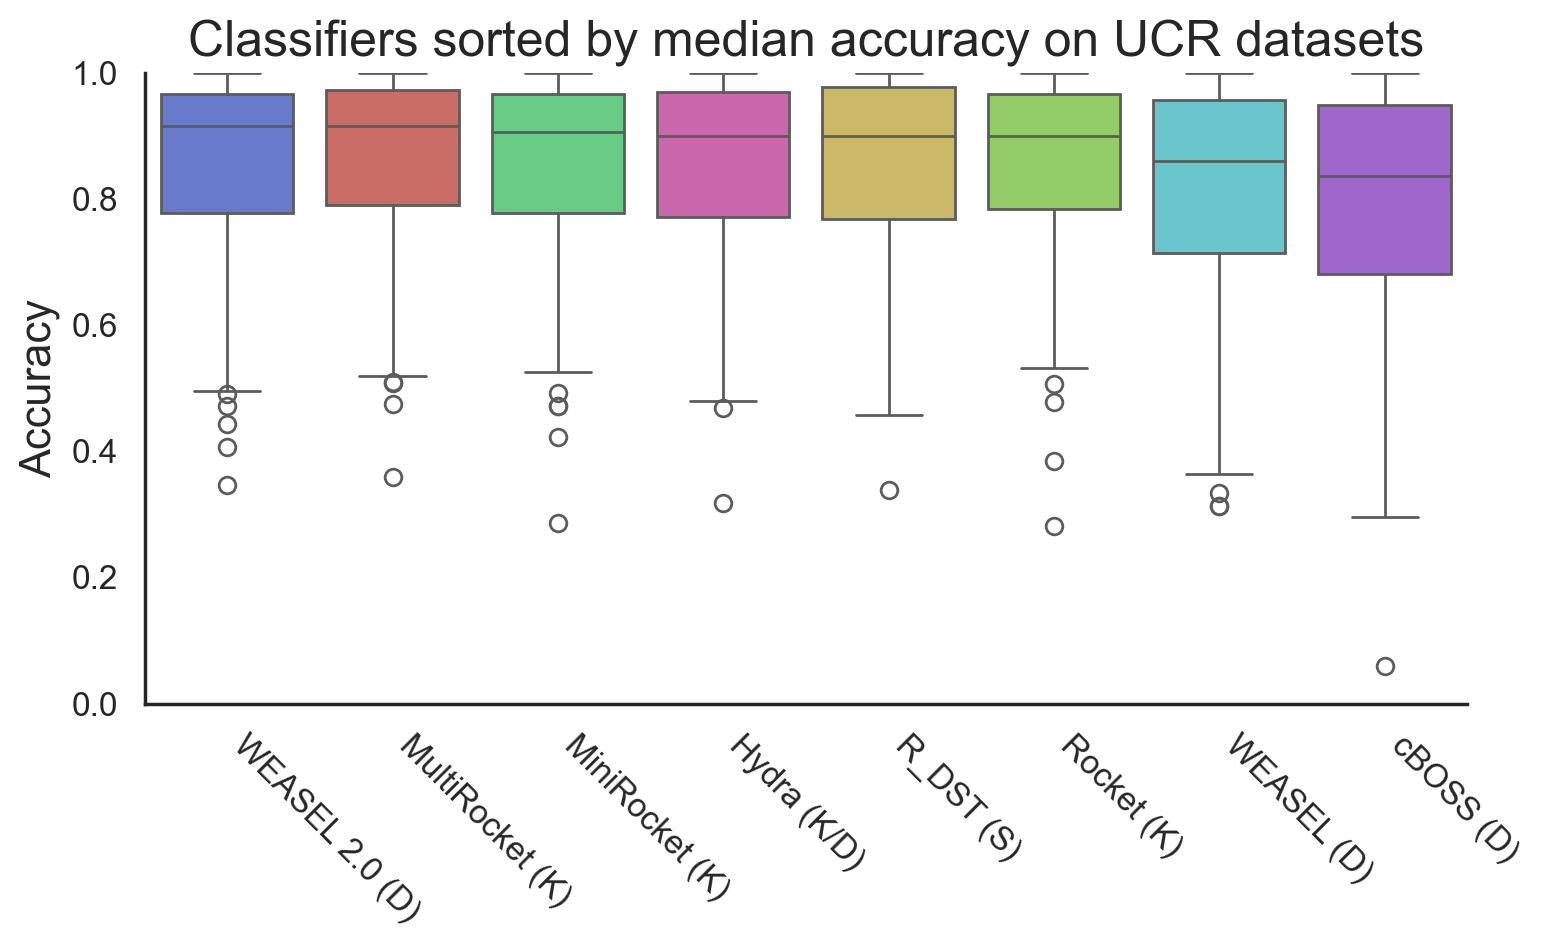

In [61]:
sns.set(font_scale=1.3)
sns.set_style("white")

print(df_clean.columns)
df_clean2 = df.dropna()


valid_datasets = df_clean.index  # datasets with no NaN across all classifiers
df_filtered = df[df["Dataset"].isin(valid_datasets)]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
g = sns.boxplot(y="Accuracy", 
                x="Classifier", 
                data=df_filtered, ax=ax, hue="Classifier", palette="hls",
                order=df_filtered.groupby("Classifier")["Accuracy"].median()
                      .sort_values(ascending=False).index)

ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, fontsize=12, ha='left')
ax.set_yticks(ax.get_yticks(), labels=ax.get_yticklabels(), fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.0, 1.0)
ax.set_title("Classifiers sorted by median accuracy on UCR datasets", fontsize=18)
sns.despine()
plt.tight_layout()

In [62]:
#def color_negative_red(val):
#    color = 'red' if val < 0 else 'black'
#    return 'color: %s' % color

#subset = [14, 8]
#subset = df_pivot.iloc[:,subset].copy()
#subset["diff"] = np.int32((subset.iloc[:,1] - subset.iloc[:,0])*100)

ds_file_name = "ucr_characteristics.csv"
datasets = pd.read_csv(f"../data/{ds_file_name}")
#df_new = pd.merge(subset, datasets, how ='inner', on =['Dataset', 'Dataset'])
#df_new.style.applymap(color_negative_red)
# df_new.to_excel("diff.xls")
#display(df_new)

In [63]:
subset = [4, 6, 8, 9, 10, 14]
df_subset2 = df_filtered #.iloc[:,subset].copy()
df_new = pd.merge(datasets, df_subset2, how ='inner', on =['Dataset', 'Dataset'])
# df_new = df_new.melt(id_vars=["Dataset", "Type"])
display(df_new.head())
df_new.to_csv("../data/ucr_subset_dataset_type.csv")

,Dataset,Train Size,Test Size,Length,No. of Classes,Type,Classifier,Accuracy,Train-Acc
0,ACSF1,100,100,1460,10,DEVICE,MultiRocket (K),0.90,0.00000
1,ACSF1,100,100,1460,10,DEVICE,R_DST (S),0.92,0.00000
2,ACSF1,100,100,1460,10,DEVICE,Rocket (K),0.88,0.00000
3,ACSF1,100,100,1460,10,DEVICE,MiniRocket (K),0.91,0.00000
4,ACSF1,100,100,1460,10,DEVICE,WEASEL (D),0.87,-0.25196


In [64]:
import warnings
warnings.simplefilter("ignore", UserWarning)
# warnings.simplefilter("ignore", FutureWarning)


#ds_file_name = "ucr_characteristics.csv"
#datasets = pd.read_csv(f"../data/{ds_file_name}")
#for t in datasets.Type.unique():
#    df_new = pd.merge(df_subset.reset_index(), datasets[datasets.Type==t], how ='inner', on =['Dataset', 'Dataset'])
#    df_new = df_new.iloc[:,:df_subset.shape[1]+1].set_index("Dataset")
#    if df_new.shape[0] > 2:
#        print(t, len(df_new))
#        df_ranks = critical_difference(df_new, False)
#        plt.show()        
#        display(df_ranks)

df_rt.head()

,Classifier,Dataset,Fit-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.17,1.83
1,MultiRocket (K),Adiac,2.20,1.45
2,MultiRocket (K),AllGestureWiimoteX,4.87,9.11
3,MultiRocket (K),AllGestureWiimoteY,5.12,9.78
4,MultiRocket (K),AllGestureWiimoteZ,5.42,9.97


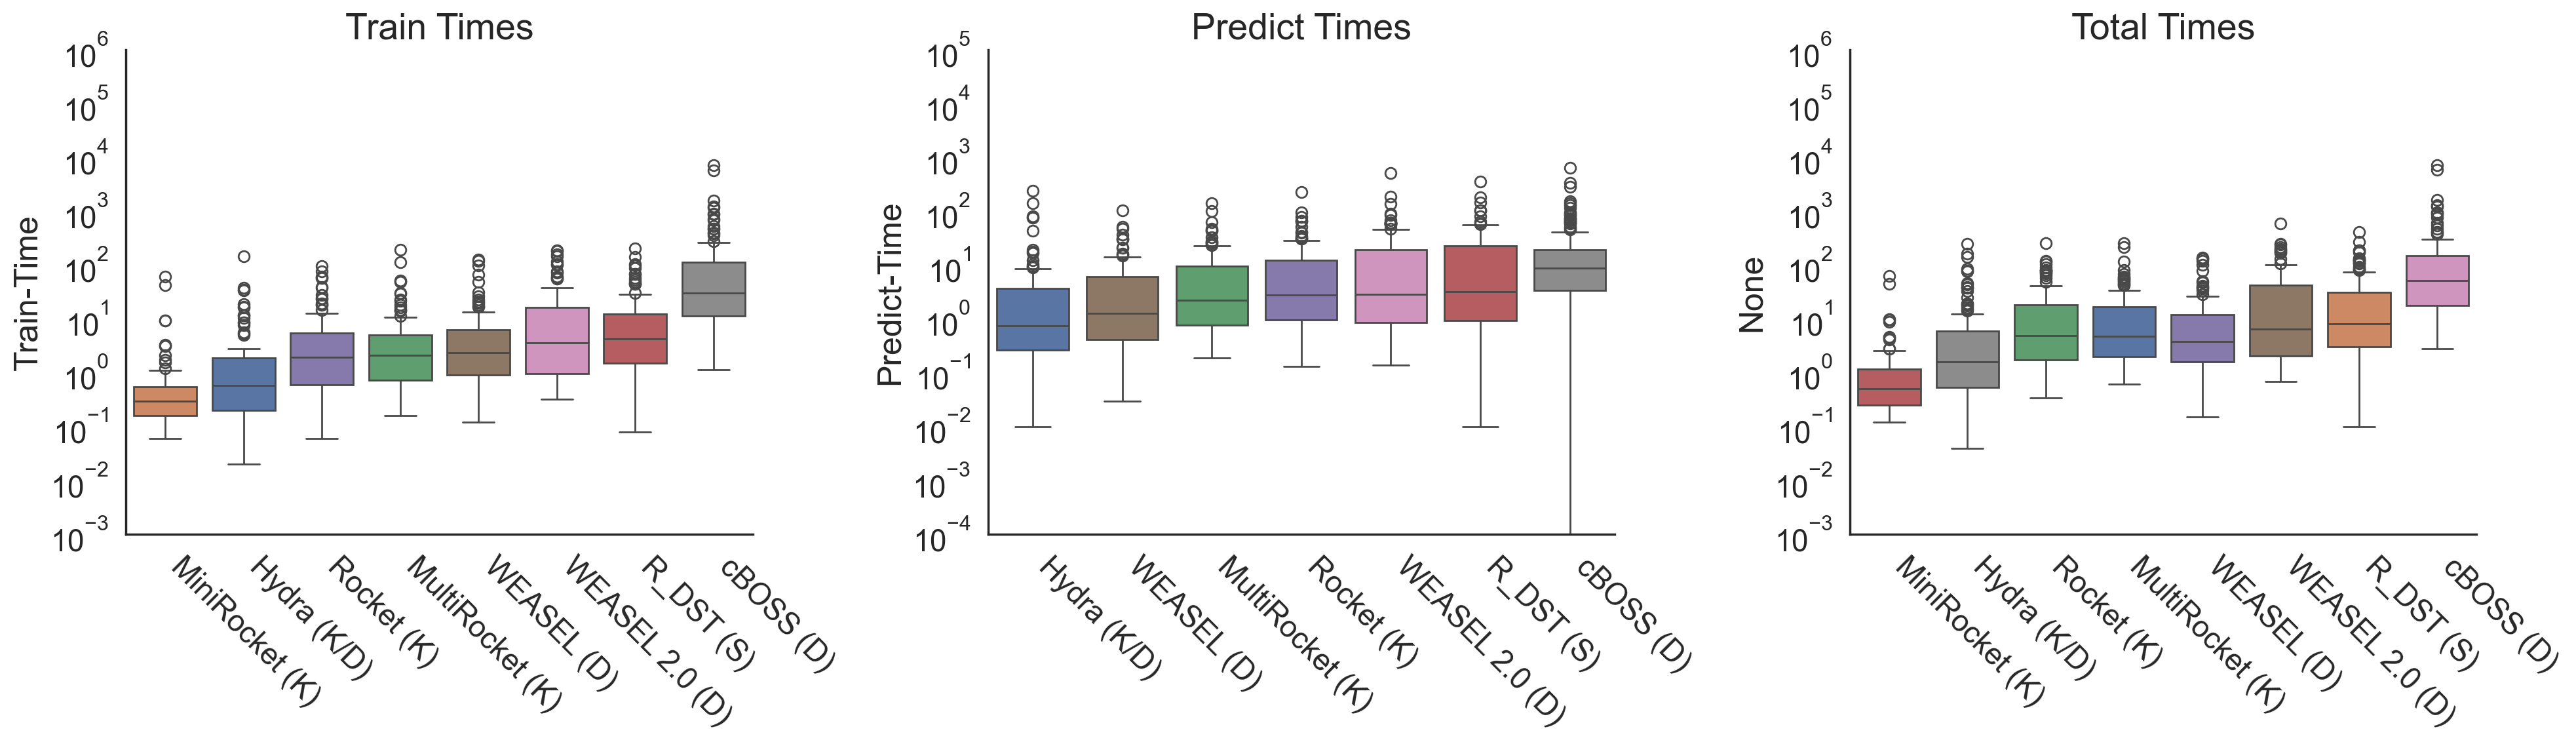

In [65]:
sns.set(font_scale=1.5)
sns.set_style("white")

df_rt.rename(columns={"Fit-Time": "Train-Time"}, inplace=True)
df_rt.dropna(inplace=True)
#df_rt = df_rt.iloc[:, subset]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
g=sns.boxplot(y="Train-Time", x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[0], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Train-Time", ascending=True).reset_index()["Classifier"])
ax=axes[0]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks(),)
ax.set_xlabel("")
ax.set_title("Train Times", fontsize=20)
sns.despine()

g=sns.boxplot(y="Predict-Time", x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[1], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Predict-Time", ascending=True).reset_index()["Classifier"][1:])
g.set_yscale("log")
ax=axes[1]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks())
ax.set_xlabel("")
ax.set_title("Predict Times", fontsize=20)
sns.despine()

g=sns.boxplot(y=df_rt["Train-Time"]+df_rt["Predict-Time"], x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[2], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Train-Time", ascending=True).reset_index()["Classifier"])
g.set_yscale("log")
ax=axes[2]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks())
plt.xlabel("")
plt.title("Total Times", fontsize=20)
sns.despine()
plt.tight_layout()

In [66]:
df_pivot_rt = df_rt.pivot(index="Dataset", columns=["Classifier"], values=["Train-Time", "Predict-Time"])
pd.DataFrame({'sum': (df_pivot_rt.sum() / 60 / 60)})

sum
             Classifier               
Train-Time   Hydra (K/D)      0.130350
             MiniRocket (K)   0.050317
             MultiRocket (K)  0.260417
             R_DST (S)        0.486417
             Rocket (K)       0.243814
             WEASEL (D)       0.269519
             WEASEL 2.0 (D)   0.607342
             cBOSS (D)        7.950925
Predict-Time Hydra (K/D)      0.266278
             MiniRocket (K)   0.016061
             MultiRocket (K)  0.337286
             R_DST (S)        0.685767
             Rocket (K)       0.432253
             WEASEL (D)       0.202961
             WEASEL 2.0 (D)   0.728319
             cBOSS (D)        1.075300

In [67]:
#pd.set_option('display.max_rows', 1000)
#display(df_pivot_rt)
df_rt # .head()

,Classifier,Dataset,Train-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.17,1.83
1,MultiRocket (K),Adiac,2.20,1.45
2,MultiRocket (K),AllGestureWiimoteX,4.87,9.11
3,MultiRocket (K),AllGestureWiimoteY,5.12,9.78
4,MultiRocket (K),AllGestureWiimoteZ,5.42,9.97
...,...,...,...,...
1015,Hydra (K/D),Wine,0.13,0.10
1016,Hydra (K/D),WordSynonyms,0.60,1.19
1017,Hydra (K/D),Worms,1.52,0.66
1018,Hydra (K/D),WormsTwoClass,1.53,0.66


In [68]:
# display(df[df.Classifier == "MrSQM_SFA_k5"])
# display(df_rt[df_rt.Classifier == "MrSQM_SFA_k5"])

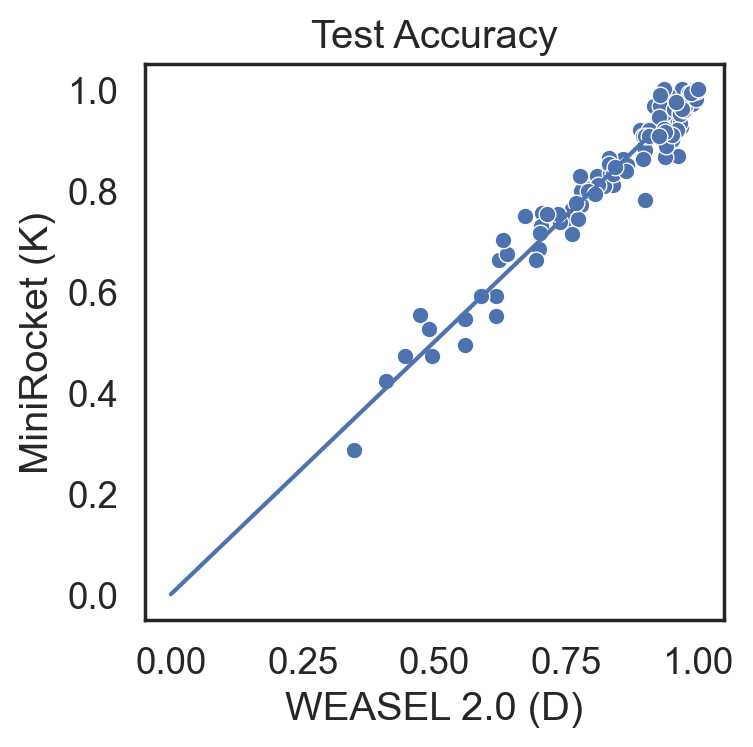

In [69]:
sns.set(font_scale=1.2)
sns.set_style("white")

key = "WEASEL 2.0 (D)"
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="MiniRocket (K)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")
plt.tight_layout()

Classifier,Hydra (K/D),WEASEL 2.0 (D)
Dataset,,


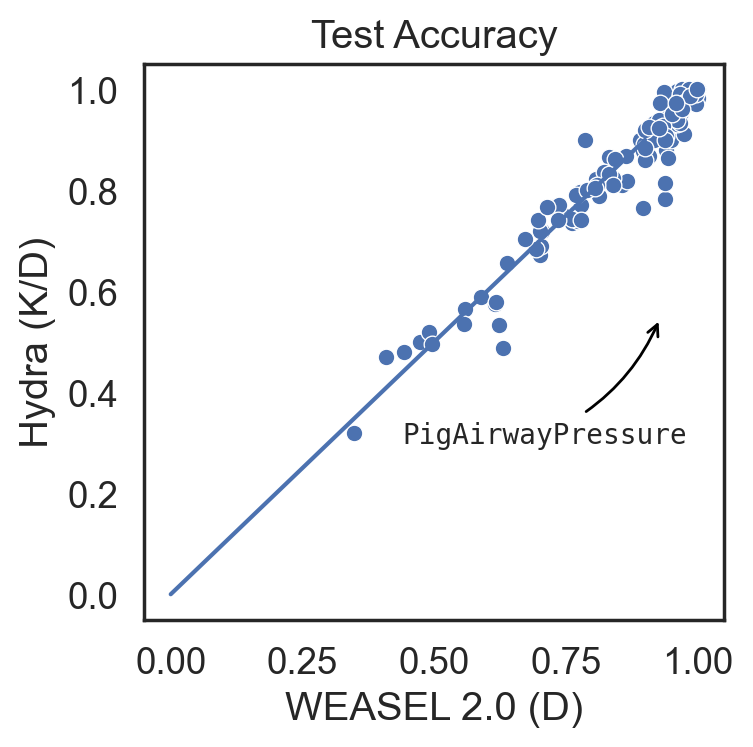

In [70]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="Hydra (K/D)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))

ax.annotate('PigAirwayPressure', xy=(0.93, 0.55), xytext=(0.44, 0.3),
             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
                             connectionstyle="arc3,rad=.2", color="Black"), 
             fontsize=10,fontfamily='monospace', ha='left');

ax.set_title("Test Accuracy")

display(df_subset[(abs(df_subset["Hydra (K/D)"]-df_subset["WEASEL 2.0 (D)"]))>0.2][["Hydra (K/D)", "WEASEL 2.0 (D)"]])
plt.tight_layout()

In [71]:
# fig, ax = plt.subplots(figsize=(4,4))
# sns.scatterplot(x=key, y="MrSQM_SFA_k5 (S/D)", data=df_subset)
# ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
# ax.set_title("Test Accuracy")

# #ax.annotate('SonyAIBORobotSurface1', xy=(0.933, 0.67), xytext=(0.38, 0.3),
# #             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
# #                             connectionstyle="arc3,rad=.2", color="Black"), 
# #             fontsize=10,fontfamily='monospace', ha='left');


# display(df_subset[(abs(df_subset["MrSQM_SFA_k5 (S/D)"]-df_subset["WEASEL 2.0 (D)"]))>0.2][["MrSQM_SFA_k5 (S/D)", "WEASEL 2.0 (D)"]])
# plt.tight_layout()

Classifier,Rocket (K),WEASEL 2.0 (D)
Dataset,,
PigAirwayPressure,0.3846,0.9375


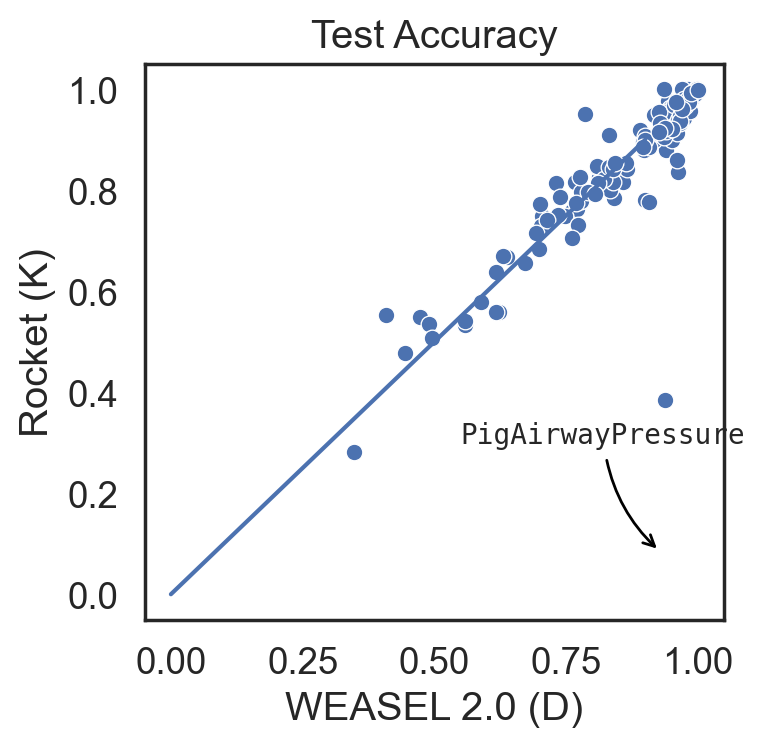

In [72]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="Rocket (K)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")

ax.annotate('PigAirwayPressure', xy=(0.93, 0.083), xytext=(0.55, 0.3),
             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
                             connectionstyle="arc3,rad=.2", color="Black"), 
             fontsize=10,fontfamily='monospace', ha='left');


display(df_subset[(abs(df_subset["Rocket (K)"]-df_subset["WEASEL 2.0 (D)"]))>0.2][["Rocket (K)", "WEASEL 2.0 (D)"]])
plt.tight_layout()

Classifier,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Dataset,,,,,,,,
PigAirwayPressure,0.7837,0.8654,0.649,0.8365,0.3846,0.8029,0.9375,0.9087


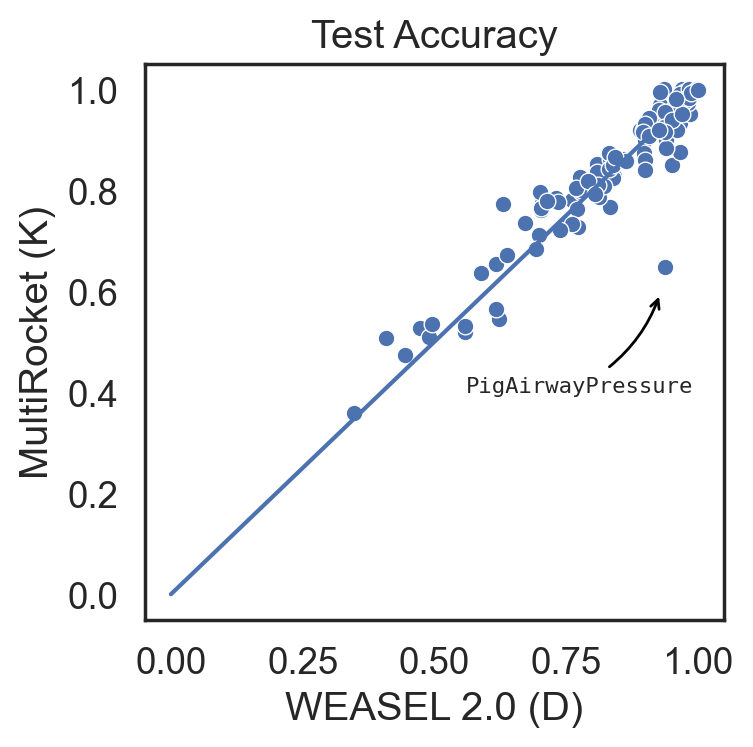

In [73]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="MultiRocket (K)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")

# annotate plot
ax.annotate('PigAirwayPressure', xy=(0.93, 0.60), xytext=(0.56, 0.4),
             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
                             connectionstyle="arc3,rad=.2", color="Black"), 
             fontsize=8,fontfamily='monospace', ha='left');


display(df_subset[(df_subset["MultiRocket (K)"]<0.65) & (df_subset["WEASEL 2.0 (D)"]>0.9)])
plt.tight_layout()

Classifier,WEASEL (D),WEASEL 2.0 (D)
Dataset,,
DodgerLoopDay,0.3896,0.6234
DodgerLoopGame,0.6220,0.8661
LargeKitchenAppliances,0.5920,0.8320
PickupGestureWiimoteZ,0.5000,0.9000
SemgHandMovementCh2,0.3133,0.6311
SemgHandSubjectCh2,0.6356,0.8956
SmoothSubspace,0.7667,0.9733


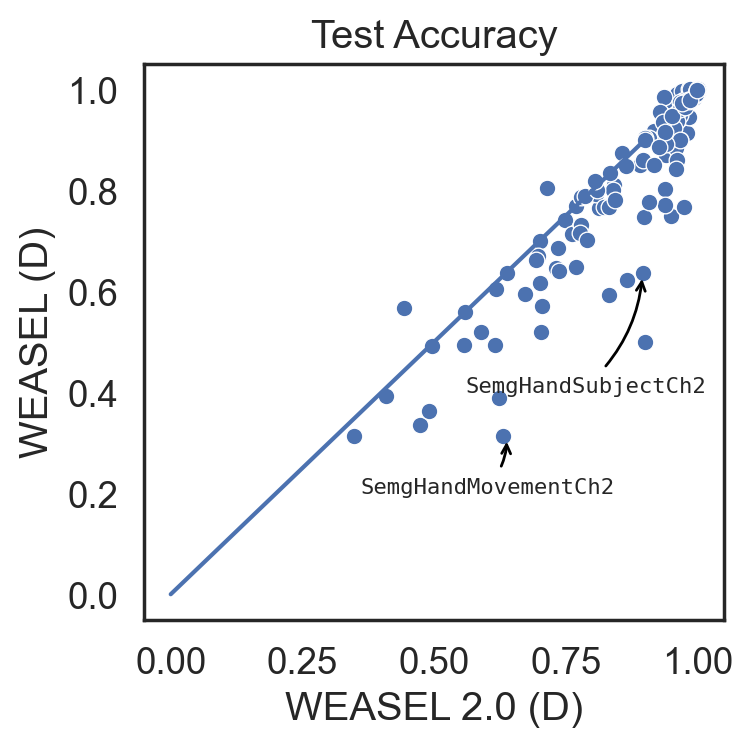

In [74]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="WEASEL (D)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")

# annotate plot
ax.annotate('SemgHandMovementCh2', xy=(0.6378, 0.3133), xytext=(0.36, 0.2),
             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
                             connectionstyle="arc3,rad=.2", color="Black"), 
             fontsize=8,fontfamily='monospace', ha='left');


ax.annotate('SemgHandSubjectCh2', xy=(0.8956, 0.6356), xytext=(0.56, 0.4),
             arrowprops=dict(facecolor='steelblue',arrowstyle="->",
                             connectionstyle="arc3,rad=.2", color="Black"), 
             fontsize=8,fontfamily='monospace', ha='left');


display(df_subset[(abs(df_subset["WEASEL (D)"]-df_subset["WEASEL 2.0 (D)"]))>0.2][["WEASEL (D)", "WEASEL 2.0 (D)"]])
plt.tight_layout()

## Weasel vs 5 SoTA Classifiers

In [75]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_weasel_UCR_comparison(df_pivot, datasets, clf_map, weasel_key,
                              type_col="Type", dataset_col="Dataset",
                              figsize=(30, 10)):

    clf_cols = list(clf_map.values())
    df = df_pivot[clf_cols].copy().reset_index()

    inv_map = {v: k for k, v in clf_map.items()}
    df = df.rename(columns=inv_map)
    clean_clfs = list(clf_map.keys())

    df = df.merge(datasets[[dataset_col, type_col]], on=dataset_col)
    df = df.dropna(subset=clean_clfs)
    df = df.sort_values([type_col, dataset_col]).reset_index(drop=True)

    df[clean_clfs] = df[clean_clfs] * 100

    df["min_acc"] = df[clean_clfs].min(axis=1)
    df["max_acc"] = df[clean_clfs].max(axis=1)

    weasel = df[weasel_key]
    others = [c for c in clean_clfs if c != weasel_key]
    best_other = df[others].max(axis=1)

    win = weasel > best_other
    tie = weasel == best_other
    loss = weasel < best_other

    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(x, df["min_acc"], df["max_acc"],
                    color="#e6a571", alpha=0.8)

    ax.plot(x, weasel, color="black", linestyle="--", linewidth=1.5)

    ax.scatter(x[win], weasel[win], color="green", s=30, zorder=3)
    ax.scatter(x[tie], weasel[tie], color="green", s=30, zorder=3)
    ax.scatter(x[loss], weasel[loss], color="red", s=30, zorder=3)

    groups = df.groupby(type_col, sort=False)
    boundaries = groups.size().cumsum()

    start = 0
    for (t, group), end in zip(groups, boundaries):
        ax.axvline(end - 0.5, linestyle="--", color="black", linewidth=1)

        mid = (start + end - 1) / 2

        ax.text(
            mid,
            20,                     # <-- above x-axis (key fix)
            t.upper(),
            rotation=-90,
            ha="center",
            va="bottom",
            fontsize=14
        )

        start = end

    ax.set_ylabel("Test Accuracy", fontsize=14)
    ax.set_title("UCR/UEA Datasets ordered by Dataset-Type", fontsize=16)

    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels([f"{i}%" for i in range(0, 101, 20)])

    ax.set_xticks(x)
    ax.set_xticklabels(df[dataset_col], rotation=90, fontsize=6, color="gray")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_elements = [
        Patch(facecolor="#e6a571", edgecolor="none", label="5 SotA classifiers"),
        Line2D([0], [0], color="black", linestyle="--", label="WEASEL 2.0")
    ]
    ax.legend(handles=legend_elements, loc="lower right", frameon=True)

    ax.text(
        1.02, 0.5,
        "higher is better",
        transform=ax.transAxes,
        rotation=90,
        va="center",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
    )

    plt.tight_layout()
    plt.show()

    return df

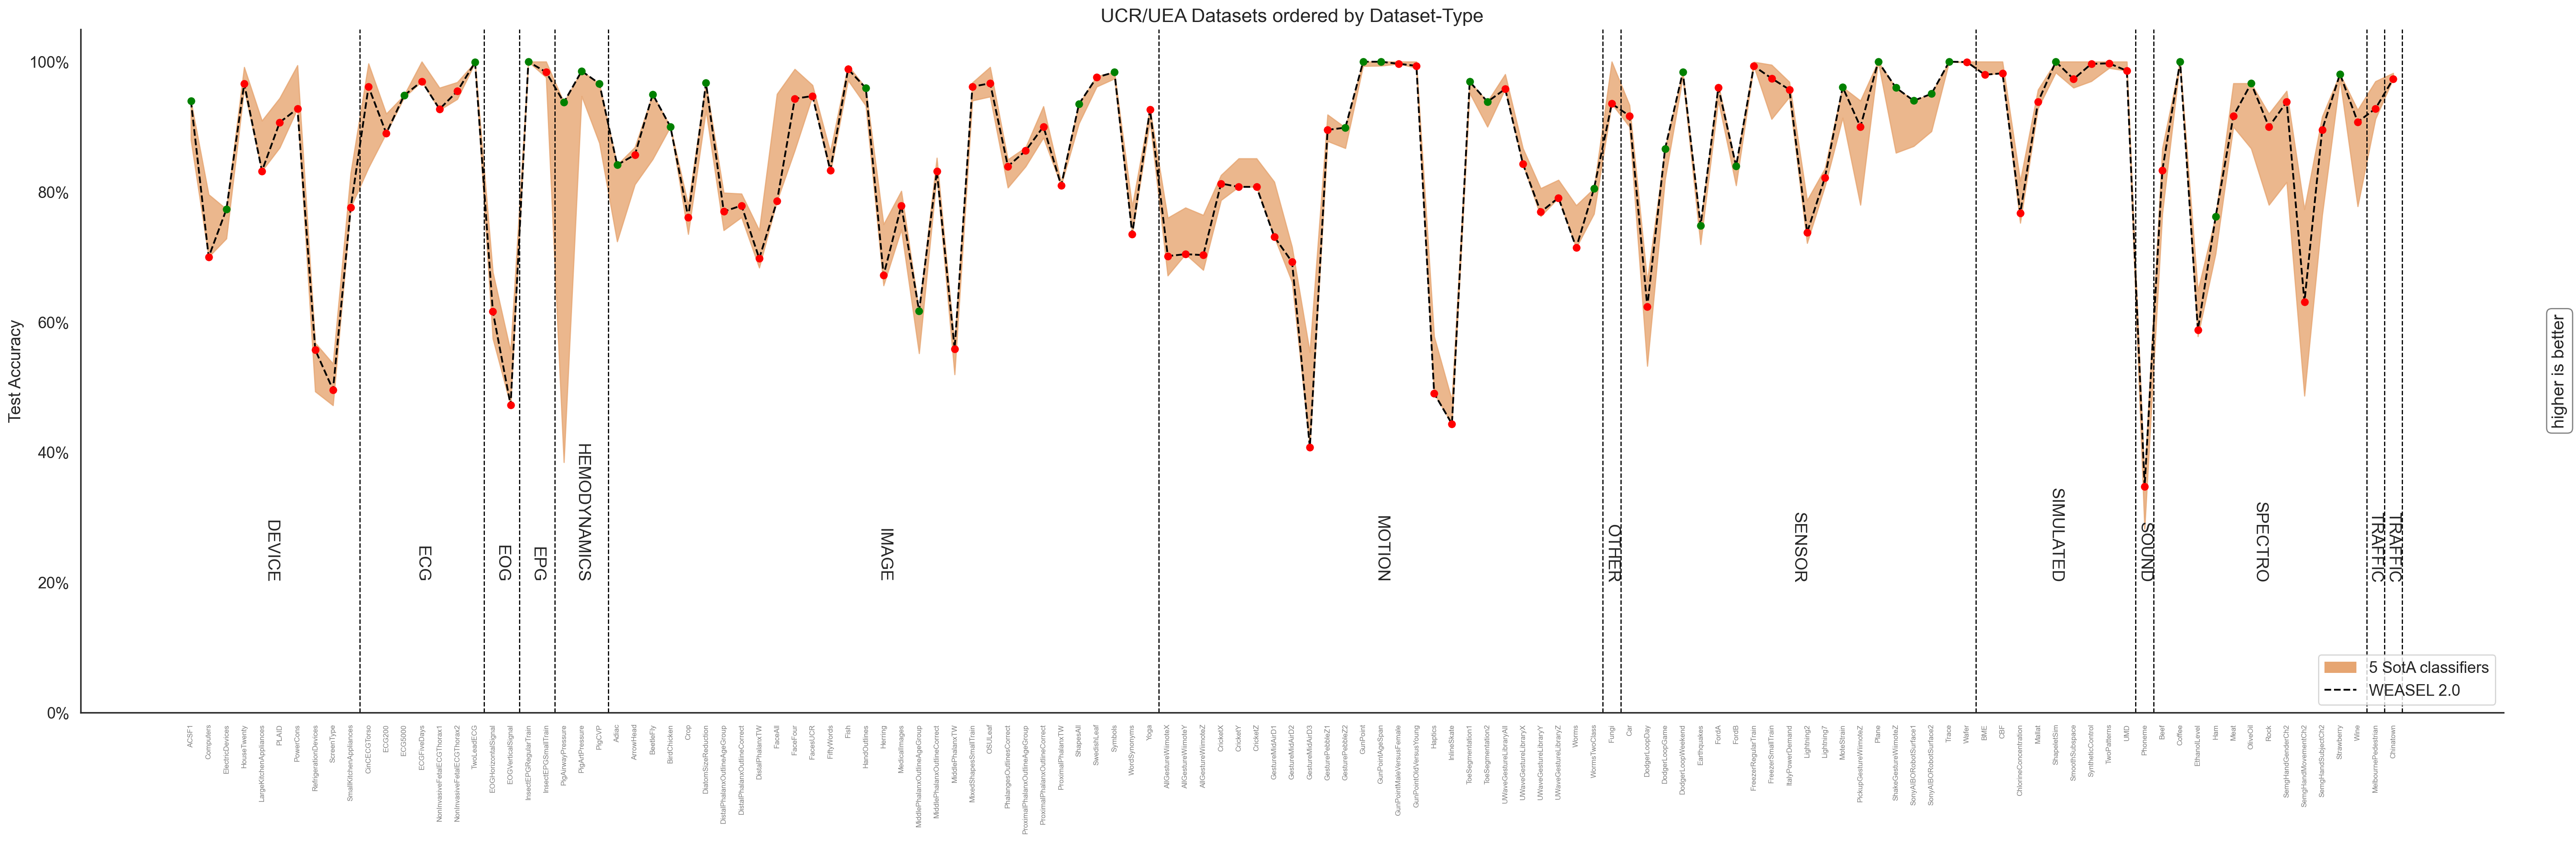

,Dataset,WEASEL 2.0,R-DST,MultiRocket,MiniRocket,Rocket,Hydra,Type,min_acc,max_acc
0,ACSF1,94.00,92.00,90.00,91.00,88.00,88.00,DEVICE,88.00,94.00
1,Computers,70.00,75.60,79.60,71.60,77.20,72.00,DEVICE,70.00,79.60
2,ElectricDevices,77.34,73.70,72.83,74.31,73.08,73.95,DEVICE,72.83,77.34
3,HouseTwenty,96.64,96.64,99.16,96.64,96.64,95.80,DEVICE,95.80,99.16
4,LargeKitchenAppliances,83.20,84.53,87.47,86.40,90.93,86.67,DEVICE,83.20,90.93
5,PLAID,90.69,93.67,94.41,91.99,88.64,86.78,DEVICE,86.78,94.41
6,PowerCons,92.78,99.44,99.44,98.89,93.33,97.22,DEVICE,92.78,99.44
7,RefrigerationDevices,55.73,56.80,53.07,49.33,54.13,53.60,DEVICE,49.33,56.80
8,ScreenType,49.60,50.40,53.60,47.20,50.67,49.60,DEVICE,47.20,53.60
9,SmallKitchenAppliances,77.60,81.87,82.67,82.93,82.67,79.73,DEVICE,77.60,82.93


In [76]:
clf_map = {
    "WEASEL 2.0": mapping["WEASEL 2.0"],
    "R-DST": mapping["R_DST"],
    "MultiRocket": mapping["MultiRocket"],
    "MiniRocket": mapping["MiniRocket"],
    "Rocket": mapping["Rocket"],
    "Hydra": mapping["Hydra (K/D)"],
}

plot_weasel_UCR_comparison(
    df_pivot,
    datasets,
    clf_map,
    "WEASEL 2.0"
)

## Figure 11

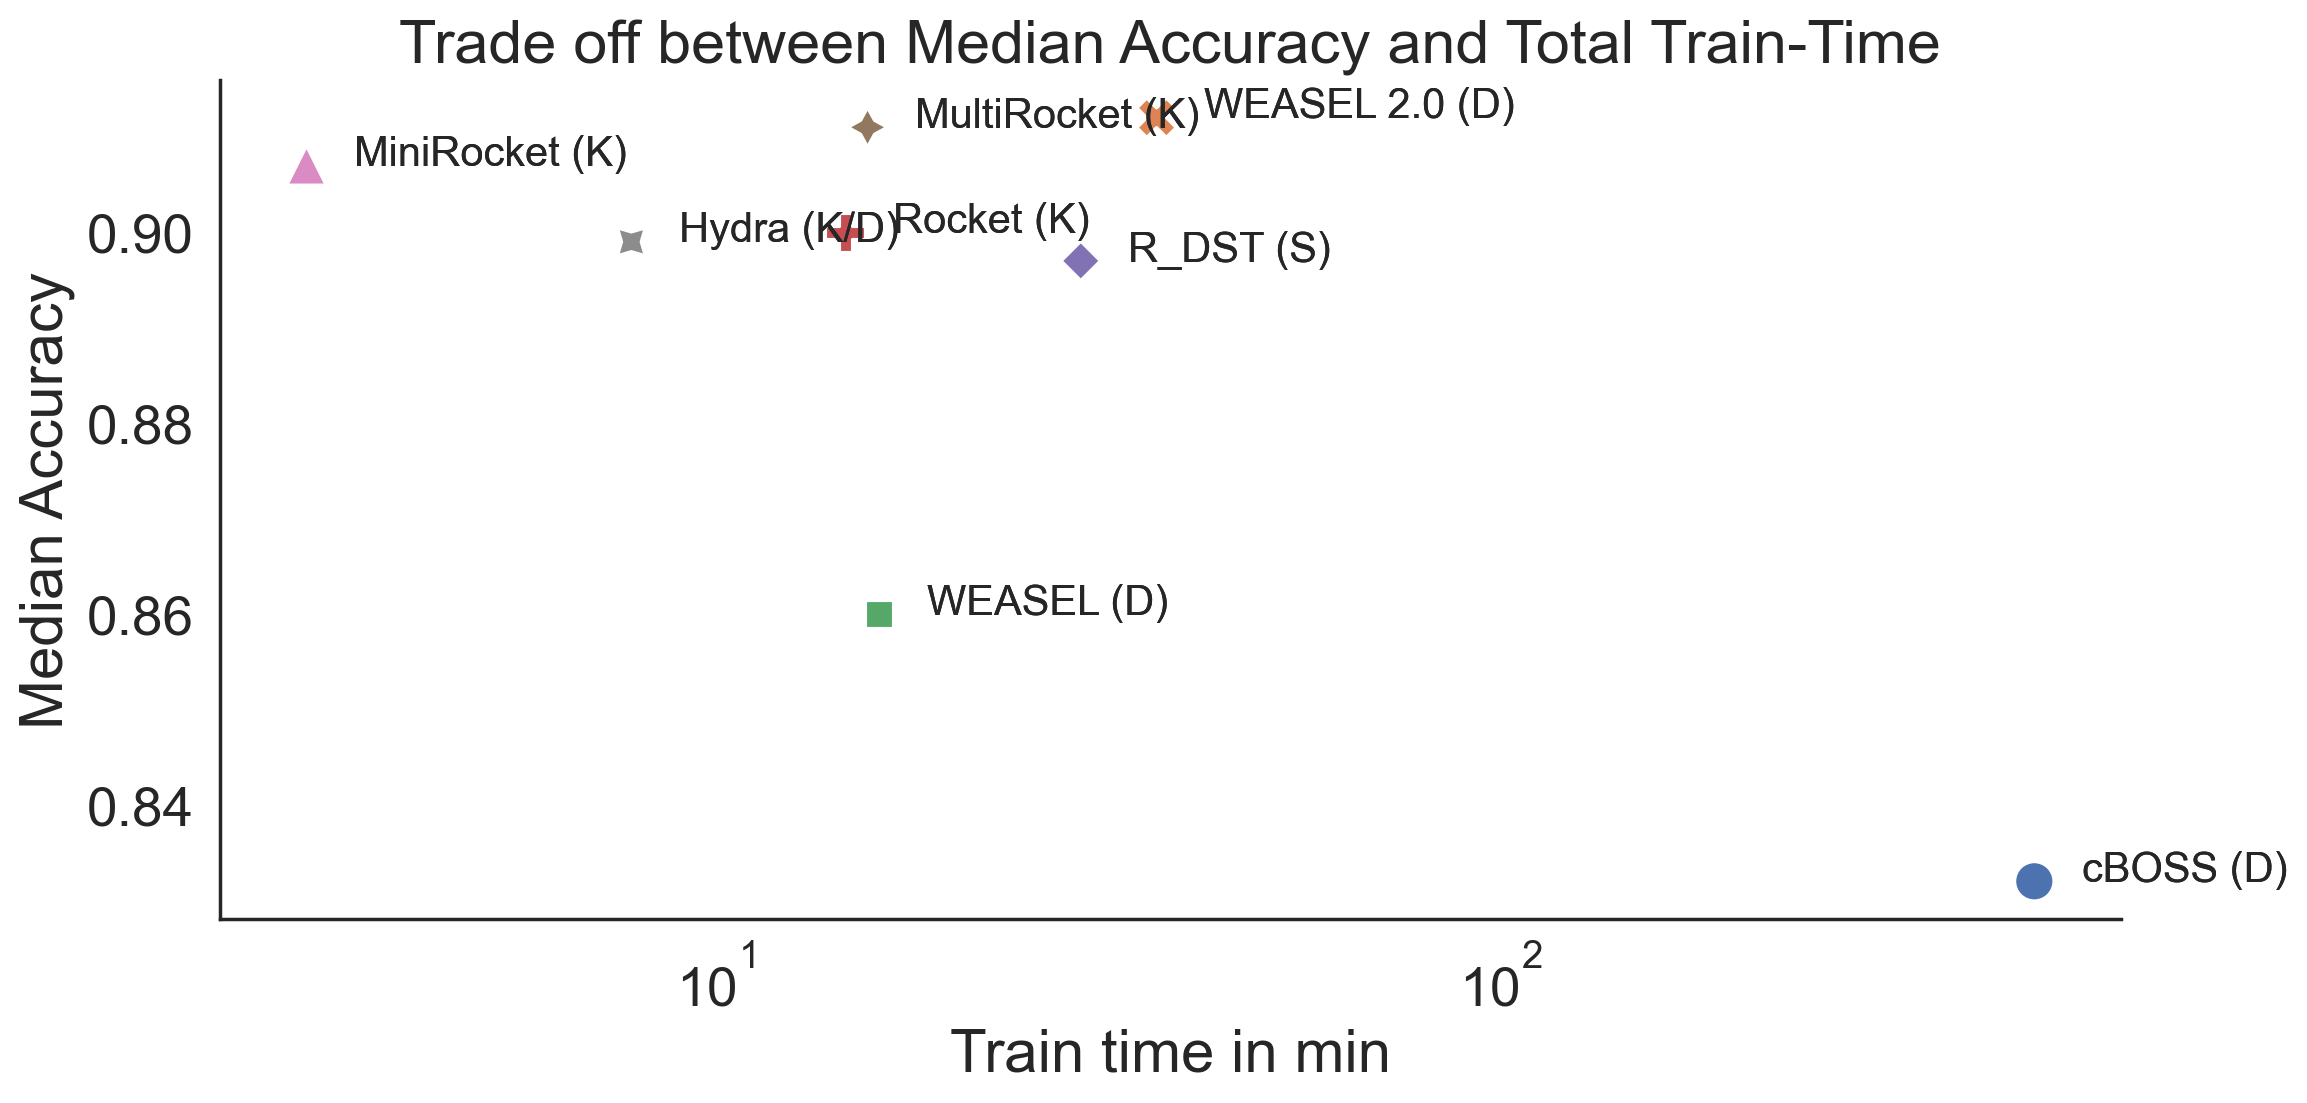

In [77]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']*1.15, point['y'], str(point['val']), fontsize=15)
        
sns.set(font_scale=1.8)
sns.set_style("white")

df_all = pd.DataFrame(columns=["Classifier", "Train time in min", "Acc"])
df = df_pivot_rt["Train-Time"]
for name in df_pivot_rt.columns[0:]:
    if name[1] in df_pivot:
        acc = np.round(df_pivot[name[1]].median(), 3)
        # print(name[1], acc)
        if name[1] in df:
            fit = np.round(df[name[1]].sum(), 3) / 60
            df_all.loc[-1] = [name[1], fit, acc]
            df_all.index = df_all.index + 1
df_all.sort_index(inplace=True)

# fig = plt.figure(figsize=(5, 5))
g = sns.relplot(x="Train time in min", y = "Acc", 
                kind="scatter", aspect=1.5, height=6,
                data=df_all, hue="Classifier", 
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")

# add title
g.ax.set_title("Trade off between Median Accuracy and Total Train-Time", fontsize=22)

# annotate plot
g.ax.annotate('(Fast & \n Accurate)', xy=(16, 0.93), xytext=(16, 0.925),
             fontsize=14,fontfamily='monospace', ha='left');

label_point(df_all["Train time in min"], df_all["Acc"], df_all["Classifier"], plt.gca())  
g._legend.remove()
plt.tight_layout()

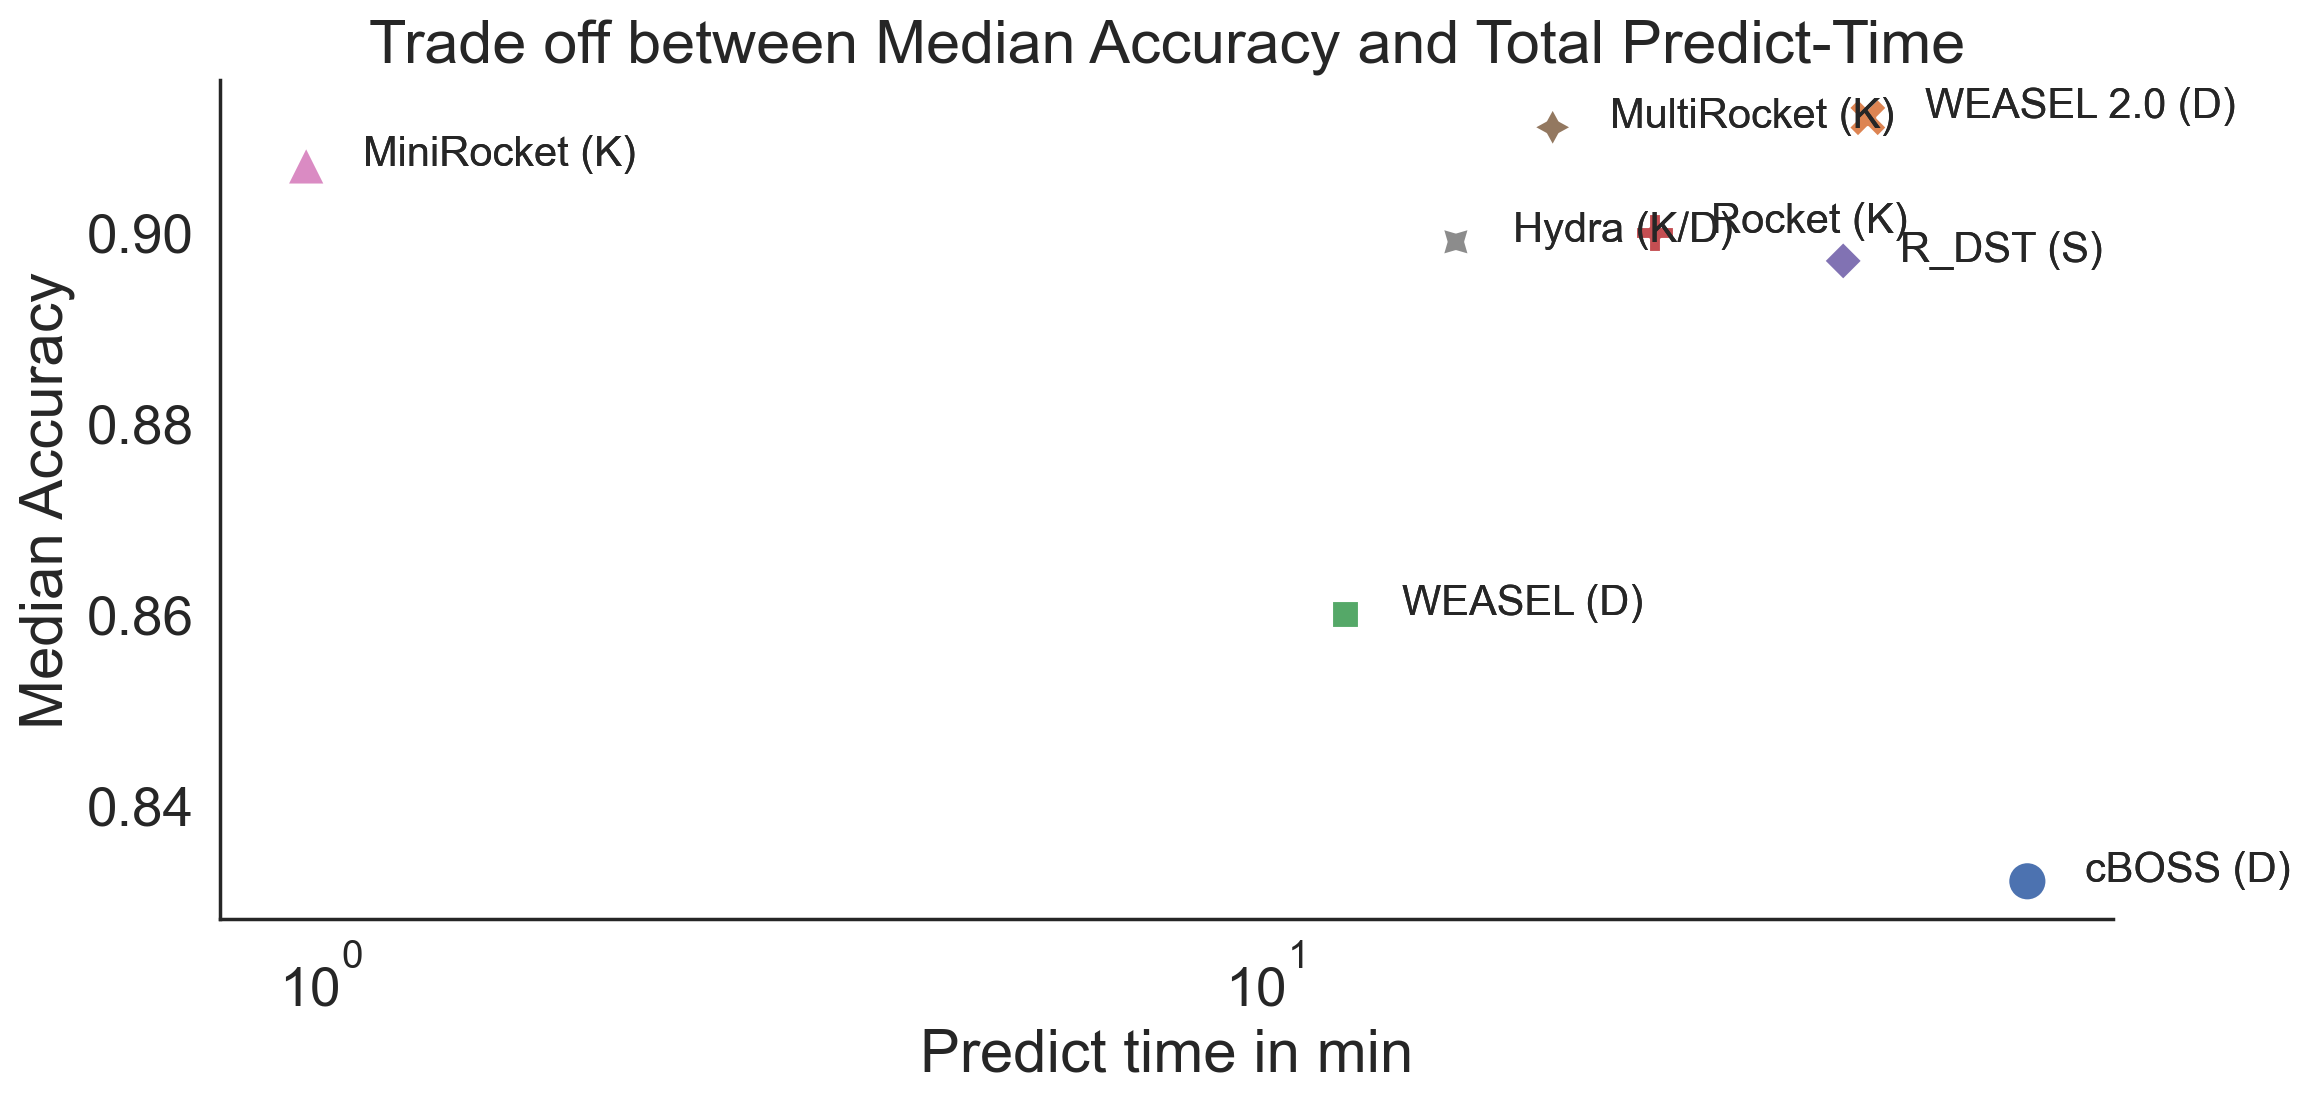

In [78]:
sns.set(font_scale=1.8)
sns.set_style("white")

df_all = pd.DataFrame(columns=["Classifier", "Predict time in min", "Acc"])
df = df_pivot_rt["Predict-Time"]
for name in df_pivot_rt.columns[0:]:
    if name[1] in df_pivot:
        acc = np.round(df_pivot[name[1]].median(), 3)
        if name[1] in df:
            fit = np.round(df[name[1]].sum(), 3) / 60
            df_all.loc[-1] = [name[1], fit, acc]
            df_all.index = df_all.index + 1
df_all.sort_index(inplace=True)
df_all = df_all[df_all["Predict time in min"] > 0]

g = sns.relplot(x="Predict time in min", y = "Acc", 
                data=df_all, hue="Classifier", aspect=1.5, height=6,
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")

# add title
g.ax.set_title("Trade off between Median Accuracy and Total Predict-Time", fontsize=22)

# annotate plot
g.ax.annotate('(Fast & \nAccurate)', xy=(16, 0.93), xytext=(16, 0.925),
             fontsize=14,fontfamily='monospace', ha='left');

g._legend.remove()
label_point(df_all["Predict time in min"], df_all["Acc"], df_all["Classifier"], g.ax)

plt.tight_layout()

## Memory

In [79]:
file_name = "ucr_feature_space.csv"
df_memory = pd.read_csv(f"../data/{file_name}")
df_memory.head()

,Classifier,Dataset,Accuracy,Fit,Predict,Features,Cross-Val
0,Hydra,ArrowHead,0.811,0.20,1.05,5120,NaN
1,Hydra,Adiac,0.818,1.75,1.49,5120,NaN
2,MultiRocket,Beef,0.767,1.91,1.47,49728,NaN
3,MiniRocket,ArrowHead,0.863,0.47,1.26,9996,NaN
4,MiniRocket,Adiac,0.841,2.46,1.81,9996,NaN


In [80]:
# df_memory.set_index("Classifier").loc[["Rocket"]]

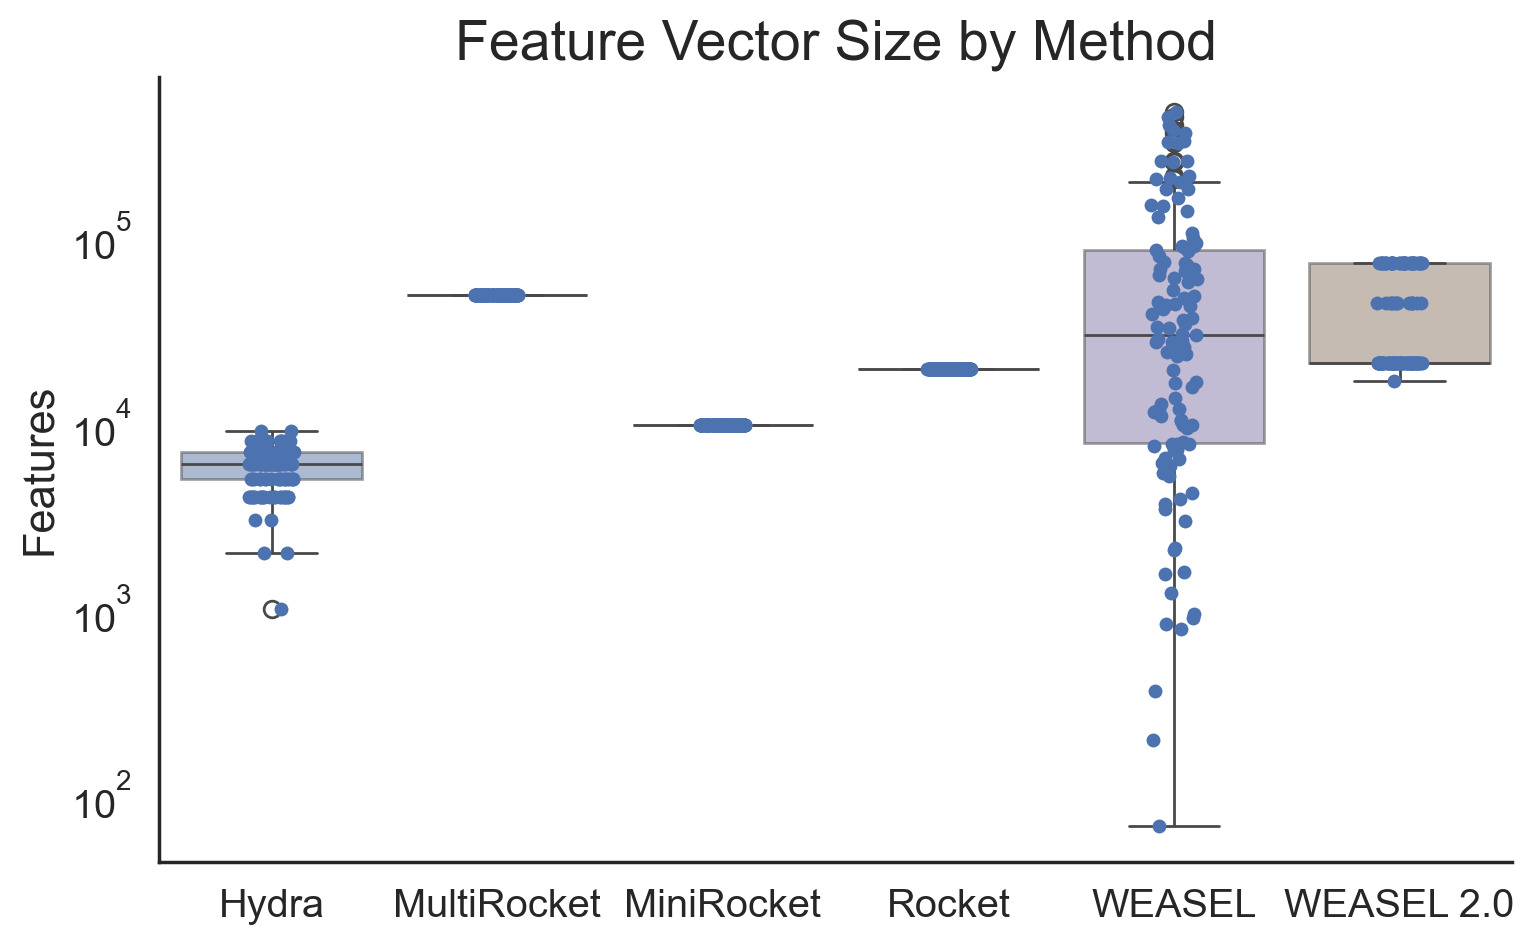

In [81]:
sns.set(font_scale=1.3)
sns.set_style("white")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax=sns.boxplot(y="Features", 
              x="Classifier", boxprops=dict(alpha=.5), hue="Classifier",
              data=df_memory, ax=ax)

sns.stripplot(y="Features", 
              x="Classifier", 
              data=df_memory, 
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
#ax.set_yticks(ax.get_yticks(), fontsize=14)
#ax.set_xticks(ax.get_xticks(), fontsize=14)
ax.set_xlabel("")
ax.set_yscale("log")
ax.set_title("Feature Vector Size by Method", fontsize=20)
sns.despine()

plt.tight_layout()

In [82]:
df_memory.set_index("Classifier").loc[["WEASEL 2.0"]].describe()

,Accuracy,Fit,Predict,Features,Cross-Val
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.863219,72.171228,74.608246,41705.052632,-0.215564
std,0.144345,167.911338,197.243697,23878.004263,0.167710
min,0.348000,0.330000,0.230000,17056.000000,-0.939184
25%,0.786000,2.275000,2.412500,21448.000000,-0.306087
50%,0.926500,13.810000,9.745000,21448.000000,-0.185489
75%,0.971250,55.402500,66.792500,73584.000000,-0.079052
max,1.000000,1143.540000,1850.290000,73584.000000,-0.006319


## Multi Comparison Matrix

Processing cBOSS (D), WEASEL 2.0 (D):   0%|          | 0/8 [00:00<?, ?it/s]      


./mcm_output/analysis.json


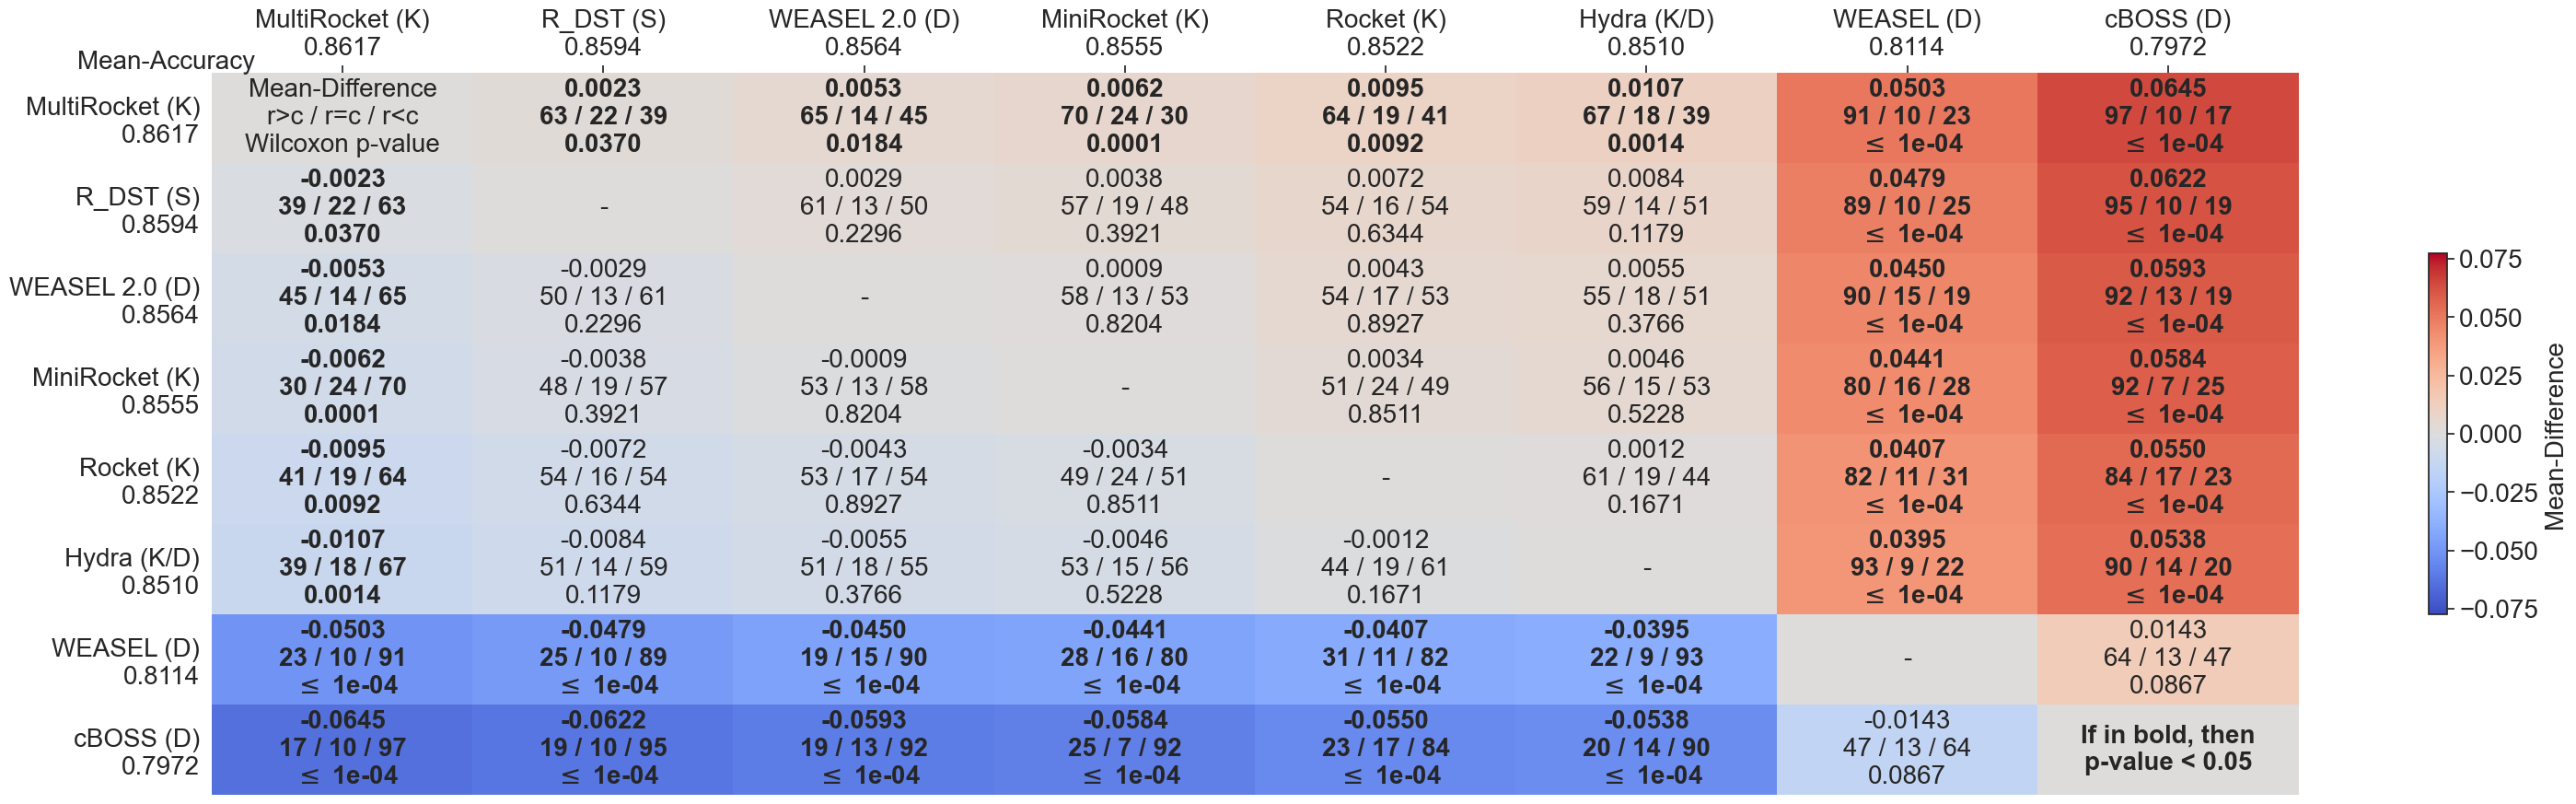

In [ ]:
df_mcm = df_clean.copy()
df_mcm.index.name = "dataset_name"

os.makedirs("./mcm_output", exist_ok=True)

MCM.compare(
    output_dir="./mcm_output/",
    df_results=df_mcm,
    pdf_savename="heatmap",
    png_savename="heatmap",
    fig_size="(14, 20)",
    font_size="20",
)

display(Image(filename="./mcm_output/heatmap.png"))

In [88]:
help(MCM.compare)

Help on function compare in module multi_comp_matrix.MCM:

compare(df_results, output_dir='./', pdf_savename=None, png_savename=None, csv_savename=None, tex_savename=None, used_statistic='Accuracy', save_as_json=True, plot_1v1_comparisons=False, order_WinTieLoss='higher', include_ProbaWinTieLoss=False, bayesian_rope=0.01, include_pvalue=True, pvalue_test='wilcoxon', pvalue_correction=None, pvalue_threshold=0.05, use_mean='mean-difference', order_stats='average-statistic', order_better='decreasing', dataset_column=None, precision=4, load_analysis=False, row_comparates=None, col_comparates=None, excluded_row_comparates=None, excluded_col_comparates=None, colormap='coolwarm', fig_size='auto', font_size='auto', colorbar_orientation='vertical', colorbar_value=None, win_label='r>c', tie_label='r=c', loss_label='r<c', include_legend=True, show_symetry=True)
    Generate the MCM

    Parameters
    ----------

    df_results              : pandas DataFrame, the csv file containing results
    

-EOF-